<a href="https://colab.research.google.com/github/MexicoHamburger/AIP-2/blob/main/CarrerPrediction_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TabTransformer Multi‑Task Workflow
엔드‑투‑엔드 예시 노트북 (10 % 샘플·train/val/test 분할 포함)

> Stack Overflow Dev Survey 2024 전처리 결과 CSV를 업로드한 뒤, **`DATA_CSV` 변수 경로만 수정**하고 셀을 순서대로 실행하세요.

In [ ]:
!pip install pandas scikit-learn torch tabtransformer-pytorch matplotlib --quiet

ERROR: Could not find a version that satisfies the requirement tabtransformer-pytorch (from versions: none)
ERROR: No matching distribution found for tabtransformer-pytorch


## 1. 데이터 로드 & 10 % 샘플링

In [ ]:
# 1. 데이터 로드 & 10 % 샘플링
import pandas as pd, numpy as np, os, random, io
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from google.colab import files

# ─── 파일 업로드 ───────────────────────────────────────────────
uploaded = files.upload()
FNAME = next(iter(uploaded))
raw = pd.read_csv(io.BytesIO(uploaded[FNAME]))

# ─── 다중-라벨 칼럼 정의 ────────────────────────────────────────
have_cols = [c for c in raw.columns if c.endswith("HaveWorkedWith")]
want_cols = [c for c in raw.columns if c.endswith("WantToWorkWith")]
other_multi = ["ProfessionalTech"]          # 입력에는 포함, Want 타깃에서는 제외
multi_cols_all = have_cols + want_cols + other_multi

def split_pipe(x):
    return [] if pd.isna(x) else [i.strip() for i in x.split(";")]

for c in multi_cols_all:
    if c in raw.columns:
        raw[c] = raw[c].apply(split_pipe)

# ─── 핵심 숫자 결측 제거 ────────────────────────────────────────
raw = raw.dropna(subset=["CompTotal", "JobSat"])

# raw = raw.sample(frac=0.10, random_state=42).reset_index(drop=True)  # 필요 시 활성화
print("샘플 수:", len(raw))


Saving SODC_2024.csv to SODC_2024.csv
샘플 수: 12275


## 2. Multi‑Label Binarizer → 입·출력 행렬

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
import numpy as np

# ── 2-1. Have 전용 토큰 공간 ────────────────────────────────
tokenizer_have = MultiLabelBinarizer()
tokenizer_have.fit(
    raw[have_cols + other_multi].apply(lambda row: sum(row, []), axis=1)
)

# ── 2-2. Want 전용 토큰 공간 ────────────────────────────────
tokenizer_want = MultiLabelBinarizer()
tokenizer_want.fit(
    raw[want_cols].apply(lambda row: sum(row, []), axis=1)
)

# ─── 입력 X  (HaveWorkedWith + ProfessionalTech) ───────────
have_tokens = raw[have_cols + other_multi].apply(
    lambda row: sum(row, []), axis=1
)
X = tokenizer_have.transform(have_tokens).astype("float32")

# ─── Want 타깃 yW  (보유 스택 제외 ‘보완 스택’) ─────────────
want_tokens = raw[want_cols].apply(lambda row: sum(row, []), axis=1)
y_want_full = tokenizer_want.transform(want_tokens).astype("float32")

# --- 보유 스택과 겹치는 토큰을 0으로 마스킹 ----------------
y_want = y_want_full.copy()
for i, hlist in enumerate(have_tokens):
    for tok in hlist:
        if tok in tokenizer_want.classes_:
            j = np.where(tokenizer_want.classes_ == tok)[0][0]
            y_want[i, j] = 0.0
n_want = y_want.shape[1]

# ─── 직군/산업 타깃 ─────────────────────────────────────────
y_role = raw["DevType"].str.get_dummies(";").astype("float32").values
y_ind  = raw["Industry"].str.get_dummies(";").astype("float32").values
n_role = y_role.shape[1]

# ─── 연봉/만족도 타깃 (직군별 행렬) ─────────────────────────
comp = raw["CompTotal"].values.astype("float64")
comp_nonan = comp[~np.isnan(comp)]
q1, q3 = np.percentile(comp_nonan, [25, 75])
iqr = q3 - q1
mean = np.mean(comp_nonan)
std = np.std(comp_nonan)
upper_bound = min(q3 + 3 * iqr, mean + 3 * std)
valid_mask = (comp < upper_bound) & (~np.isnan(comp))

scaler = StandardScaler()
scaled_valid = scaler.fit_transform(comp[valid_mask].reshape(-1, 1)).flatten()

y_sal_scalar = np.full_like(comp, np.nan, dtype="float32")
y_sal_scalar[valid_mask] = scaled_valid.astype("float32")
y_sat_scalar = raw["JobSat"].astype("float32").values

y_sal_mat = np.tile(y_sal_scalar[:, None], (1, n_role))
y_sat_mat = np.tile(y_sat_scalar[:, None], (1, n_role))
y_sal_role = np.where(y_role == 1, y_sal_mat, np.nan).astype("float32")
y_sat_role = np.where(y_role == 1, y_sat_mat, np.nan).astype("float32")

print("X shape      :", X.shape)
print("y_want       :", y_want.shape)
print("y_role shape :", y_role.shape)


X shape      : (12275, 102)
y_want       : (12275, 93)
y_role shape : (12275, 17)


## 3. train / val / test 3‑way split

In [ ]:
from sklearn.model_selection import train_test_split

TEST_RATIO = 0.10
VAL_RATIO  = 0.15

split_data = train_test_split(
    X, y_role, y_ind, y_sal_role, y_sat_role, y_want,
    test_size=TEST_RATIO, random_state=42
)

(X_tmp, X_test,
 yR_tmp, yR_test,
 yI_tmp, yI_test,
 yS_tmp, yS_test,
 yT_tmp, yT_test,
 yW_tmp, yW_test) = split_data

val_ratio_adj = VAL_RATIO / (1 - TEST_RATIO)
X_train, X_val, yR_train, yR_val, yI_train, yI_val, yS_train, yS_val, yT_train, yT_val, yW_train, yW_val = train_test_split(
    X_tmp, yR_tmp, yI_tmp, yS_tmp, yT_tmp, yW_tmp,
    test_size=val_ratio_adj, random_state=42
)

for name, arr in [("train", X_train), ("val", X_val), ("test", X_test)]:
    print(f"{name:<5} {arr.shape[0]:>6} samples")


train   9205 samples
val     1842 samples
test    1228 samples


## 4. TabTransformer 모델 정의

In [ ]:
# 4. TabTransformer + Dual Head 모델 정의
# ─────────────────────────────────────────────────────────────
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np

class TabTransformer(nn.Module):
    def __init__(self, input_dim, embed_dim=256, depth=6, heads=8, dropout=0.3):
        super().__init__()
        self.embedding = nn.Linear(input_dim, embed_dim)
        enc = nn.TransformerEncoderLayer(
            embed_dim, heads, embed_dim * 4,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc, num_layers=depth)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):                      # x : (B, D_have)
        x = self.embedding(x).unsqueeze(1)     # (B,1,E)
        x = self.encoder(x)                    # (B,1,E)
        return self.dropout(x.mean(1))         # (B,E)

class ResidualAdapter(nn.Module):
    def __init__(self, dim, bottleneck=128):
        super().__init__()
        self.adapter = nn.Sequential(
            nn.Linear(dim, bottleneck),
            nn.ReLU(),
            nn.Linear(bottleneck, dim)
        )
    def forward(self, x):                      # (B,E)
        return x + self.adapter(x)

class MultiTaskTab(nn.Module):
    """
    - backbone 입력: Have one-hot 벡터 (tokenizer_have 차원)
    - want_head 출력: Want tokenizer 차원(n_want)
    """
    def __init__(self, in_dim_have, n_role, n_ind, n_want):
        super().__init__()
        self.backbone = TabTransformer(in_dim_have)         # Have 전용

        # 각 태스크별 어댑터
        self.role_proj = ResidualAdapter(256)
        self.ind_proj  = ResidualAdapter(256)
        self.sal_proj  = ResidualAdapter(256)
        self.sat_proj  = ResidualAdapter(256)
        self.want_proj = ResidualAdapter(256)               # Want 전용

        # Head
        self.role_head = nn.Sequential(
            nn.LayerNorm(256), nn.Linear(256, n_role), nn.Sigmoid()
        )
        self.ind_head  = nn.Sequential(
            nn.LayerNorm(256), nn.Linear(256, n_ind), nn.Sigmoid()
        )
        self.want_head = nn.Sequential(
            nn.LayerNorm(256), nn.Linear(256, n_want), nn.Sigmoid()
        )
        self.sal_head  = nn.Sequential(nn.LayerNorm(256), nn.Linear(256, n_role))
        self.sat_head  = nn.Sequential(nn.LayerNorm(256), nn.Linear(256, n_role))

    def forward(self, x):                      # x : (B, D_have)
        feat = self.backbone(x)
        return (
            self.role_head(self.role_proj(feat)),
            self.ind_head (self.ind_proj (feat)),
            self.sal_head (self.sal_proj (feat)),
            self.sat_head (self.sat_proj (feat)),
            self.want_head(self.want_proj(feat)),
        )

# --- 예시 업스킬 유틸: dual tokenizer 반영 --------------------
@torch.no_grad()
def predict_with_upskill(
    model,
    x_have_np: np.ndarray,
    tokenizer_have,
    tokenizer_want,
    top_k: int = 3,
    device: str = "cpu",
):
    """
    1) 현재 보유 스택 have → 모델 추론
    2) want 확률에서 이미 보유한 토큰 제외 후 top-k
    """
    x = torch.tensor(x_have_np, dtype=torch.float32).to(device)
    r, i, s, t, w = model(x)
    r, i, s, t, w = (arr.cpu().numpy()[0] for arr in (r, i, s, t, w))

    # --- have → want 공간 매핑 마스크 -----------------------
    have_indices = np.where(x_have_np[0] == 1)[0]
    have_tokens  = set(tokenizer_have.classes_[have_indices])
    have_mask_w  = np.isin(tokenizer_want.classes_, list(have_tokens)).astype(np.float32)

    w_filtered = w * (1 - have_mask_w)
    top_idx = w_filtered.argsort()[-top_k:][::-1]

    return {
        "role_prob": r,
        "industry_prob": i,
        "salary": s,
        "satisfaction": t,
        "want_prob": w,
        "topk_stack_idx": top_idx,
    }


## 5. DataLoader & 하이퍼파라미터 설정

In [ ]:
%env CUDA_LAUNCH_BLOCKING=1


env: CUDA_LAUNCH_BLOCKING=1


In [ ]:
# 5. DataLoader & 하이퍼파라미터
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

def make_loader(X, yR, yI, yS, yT, yW, bs, shuffle):
    yS = np.nan_to_num(yS, nan=0.0)
    yT = np.nan_to_num(yT, nan=0.0)
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(yR, dtype=torch.float32),
        torch.tensor(yI, dtype=torch.float32),
        torch.tensor(yS, dtype=torch.float32),
        torch.tensor(yT, dtype=torch.float32),
        torch.tensor(yW, dtype=torch.float32),
    )
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

tr_loader  = make_loader(X_train, yR_train, yI_train, yS_train, yT_train, yW_train, bs=256, shuffle=True)
val_loader = make_loader(X_val,   yR_val,   yI_val,   yS_val,   yT_val,   yW_val,   bs=512, shuffle=False)
test_loader= make_loader(X_test,  yR_test,  yI_test,  yS_test,  yT_test,  yW_test,  bs=512, shuffle=False)

model = MultiTaskTab(X.shape[1], n_role, y_ind.shape[1], n_want).to(device)
opt   = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

class FocalBCELoss(nn.Module):
    def __init__(self, gamma=2.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, input, target):
        bce = F.binary_cross_entropy(input, target, reduction='none')
        pt = torch.where(target == 1, input, 1 - input)
        focal = (1 - pt) ** self.gamma * bce
        return focal.mean() if self.reduction == 'mean' else focal.sum()

# smooth regression loss
smooth_l1 = nn.SmoothL1Loss()

# 통합 loss
def loss_fn(outputs, yR, yI, yS, yT, yW):
    r, i, s, t, w = outputs

    loss_role = F.binary_cross_entropy(r, yR)
    loss_ind  = F.binary_cross_entropy(i, yI)
    loss_want = FocalBCELoss(gamma=2.0)(w, yW)

    mask = (yR > 0.5)  # 역할 기반 마스킹
    s_loss = smooth_l1(s[mask], yS[mask])
    t_loss = smooth_l1(t[mask], yT[mask])

    return (
        loss_role +
        loss_ind +
        loss_want +
        0.008 * s_loss +
        0.25  * t_loss
    )


## 6. 학습 루프 (early stopping, 과적합 관찰)

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR

scheduler = CosineAnnealingLR(opt, T_max=30, eta_min=1e-6)
# 6. 학습 루프
EPOCHS   = 1000
PATIENCE = 20
BEST_VAL = float('inf')
WAIT     = 0
BEST_STATE = None
history = {"train": [], "val": [], "lr": []}

for ep in range(1, EPOCHS + 1):
    # ── train ───────────────────────────────────────────────
    model.train()
    total_loss, n_total = 0.0, 0
    for xb, yR, yI, yS, yT, yW in tr_loader:
        xb, yR, yI, yS, yT, yW = xb.to(device), yR.to(device), yI.to(device), yS.to(device), yT.to(device), yW.to(device)
        opt.zero_grad()
        loss = loss_fn(model(xb), yR, yI, yS, yT, yW)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        total_loss += loss.item() * len(xb)
        n_total += len(xb)
    history["train"].append(total_loss / n_total)

    # ── val ─────────────────────────────────────────────────
    model.eval()
    val_loss, n_val = 0.0, 0
    with torch.no_grad():
        for xb, yR, yI, yS, yT, yW in val_loader:
            xb, yR, yI, yS, yT, yW = xb.to(device), yR.to(device), yI.to(device), yS.to(device), yT.to(device), yW.to(device)
            vl = loss_fn(model(xb), yR, yI, yS, yT, yW)
            if not (torch.isnan(vl) or torch.isinf(vl)):
                val_loss += vl.item() * len(xb)
                n_val += len(xb)
    val_avg = val_loss / n_val
    history["val"].append(val_avg)
    print(f"Ep {ep:03d} | train {history['train'][-1]:.4f} | val {val_avg:.4f}")
    scheduler.step()
    print(f"→ current lr: {opt.param_groups[0]['lr']:.6f}")
    history["lr"].append(opt.param_groups[0]['lr'])

    if val_avg < BEST_VAL:
        BEST_VAL = val_avg; WAIT = 0; BEST_STATE = model.state_dict(); BEST_EP = ep
    else:
        WAIT += 1
        if WAIT >= PATIENCE:
            print(f"🛑 Early stop @ {ep} (best {BEST_EP})"); break

model.load_state_dict(BEST_STATE)


Ep 001 | train 2.0258 | val 1.2380
→ current lr: 0.000100
Ep 002 | train 1.2146 | val 0.9528
→ current lr: 0.000099
Ep 003 | train 0.9352 | val 0.8098
→ current lr: 0.000098
Ep 004 | train 0.8100 | val 0.7488
→ current lr: 0.000096
Ep 005 | train 0.7432 | val 0.7113
→ current lr: 0.000093
Ep 006 | train 0.7040 | val 0.6908
→ current lr: 0.000091
Ep 007 | train 0.6805 | val 0.6748
→ current lr: 0.000087
Ep 008 | train 0.6656 | val 0.6674
→ current lr: 0.000084
Ep 009 | train 0.6561 | val 0.6605
→ current lr: 0.000080
Ep 010 | train 0.6504 | val 0.6551
→ current lr: 0.000075
Ep 011 | train 0.6447 | val 0.6504
→ current lr: 0.000071
Ep 012 | train 0.6416 | val 0.6463
→ current lr: 0.000066
Ep 013 | train 0.6383 | val 0.6462
→ current lr: 0.000061
Ep 014 | train 0.6356 | val 0.6449
→ current lr: 0.000056
Ep 015 | train 0.6335 | val 0.6406
→ current lr: 0.000051
Ep 016 | train 0.6333 | val 0.6430
→ current lr: 0.000045
Ep 017 | train 0.6314 | val 0.6416
→ current lr: 0.000040
Ep 018 | train

<All keys matched successfully>

## 7. Train vs Val Loss 곡선

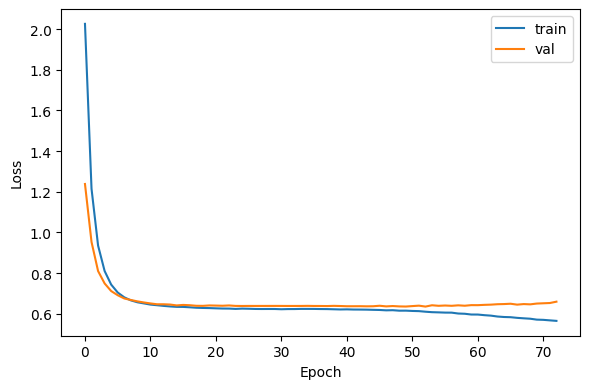

In [ ]:
# 7. Train vs Val Loss
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(history["train"], label="train")
plt.plot(history["val"],   label="val")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.tight_layout(); plt.show()


## 8. Test 세트 최종 평가

In [ ]:
# 8. Test 세트 평가
from sklearn.metrics import recall_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

def recall_at_k(y_true, y_prob, k):
    topk = np.argsort(-y_prob, axis=1)[:, :k]
    return np.mean([y_true[i, idx].max() for i, idx in enumerate(topk)])

# --- [수정] want_recall에서 tokenizer_want 기준의 have_mask 생성
def build_have_mask(tokenizer_have, tokenizer_want, X_have):
    """
    입력: X_test (have tokenizer 기준 one-hot)
    출력: have_mask (want tokenizer 기준 0/1)
    """
    mask = np.zeros((X_have.shape[0], len(tokenizer_want.classes_)), dtype=np.float32)
    for i in range(X_have.shape[0]):
        have_idx = np.where(X_have[i] == 1)[0]
        have_tokens = tokenizer_have.classes_[have_idx]
        match = np.isin(tokenizer_want.classes_, have_tokens)
        mask[i] = match.astype(np.float32)
    return mask

def want_recall_at_1(y_true, y_prob, have_mask):
    y_prob = y_prob * (1 - have_mask)
    top1 = np.argmax(y_prob, axis=1)
    hits = [(y_true[i, top1[i]] > 0.5) for i in range(len(top1))]
    return np.mean(hits)

def want_recall_at_3(y_true, y_prob, have_mask):
    y_prob = y_prob * (1 - have_mask)
    top3 = np.argsort(-y_prob, axis=1)[:, :3]
    hits = [(y_true[i, idx] > 0.5).any() for i, idx in enumerate(top3)]
    return np.mean(hits)

# --- 모델 추론
model.eval()
R_dl, I_dl, S_dl_full, T_dl_full, W_dl = [], [], [], [], []
with torch.no_grad():
    for xb, _, _, _, _, _ in test_loader:
        xb = xb.to(device)
        r, i, s, t, w = model(xb)
        R_dl.append(r.cpu()); I_dl.append(i.cpu())
        S_dl_full.append(s.cpu()); T_dl_full.append(t.cpu())
        W_dl.append(w.cpu())
R_dl  = torch.cat(R_dl).numpy()
I_dl  = torch.cat(I_dl).numpy()
S_dl_full = torch.cat(S_dl_full).numpy()
T_dl_full = torch.cat(T_dl_full).numpy()
W_dl  = torch.cat(W_dl).numpy()

# --- role별 salary/satisfaction 추출
max_idx_dl = R_dl.argmax(1)
S_dl = S_dl_full[np.arange(len(X_test)), max_idx_dl]
T_dl = T_dl_full[np.arange(len(X_test)), max_idx_dl]

# --- [추가] have_mask_want 생성
have_mask_want = build_have_mask(tokenizer_have, tokenizer_want, X_test)

# --- Want Recall 계산
want_r1 = want_recall_at_1(yW_test, W_dl, have_mask_want)
want_r3 = want_recall_at_3(yW_test, W_dl, have_mask_want)

# --- 기타 공통 메트릭
def eval_common(name, R_pred, I_pred, S_pred, T_pred):
    r1 = recall_at_k(yR_test, R_pred, 1); r3 = recall_at_k(yR_test, R_pred, 3)
    i1 = recall_at_k(yI_test, I_pred, 1); i3 = recall_at_k(yI_test, I_pred, 3)

    true_sal_raw = np.nanmax(yS_test, 1); valid = ~np.isnan(true_sal_raw)
    sal_mae = mean_absolute_error(
        scaler.inverse_transform(true_sal_raw[valid,None])[:,0],
        scaler.inverse_transform(S_pred[valid,None])[:,0]
    )

    true_sat_raw = np.nanmax(yT_test, 1); valid_t = ~np.isnan(true_sat_raw)
    sat_rmse = np.sqrt(mean_squared_error(true_sat_raw[valid_t], T_pred[valid_t]))

    return pd.Series({
        "Recall@1_role": r1, "Recall@3_role": r3,
        "Recall@1_ind": i1,  "Recall@3_ind": i3,
        "Salary_MAE": sal_mae, "Satisfaction_RMSE": sat_rmse
    }, name=name)

# --- 결과 출력
results = pd.concat([
    eval_common("TabTransformer", R_dl, I_dl, S_dl, T_dl)
], axis=1).T
results["Want_Recall@1"] = want_r1
results["Want_Recall@3"] = want_r3
print(results.round(4))


                Recall@1_role  Recall@3_role  Recall@1_ind  Recall@3_ind  \
TabTransformer         0.6099         0.8705        0.4039        0.5505   

                Salary_MAE  Satisfaction_RMSE  Want_Recall@1  Want_Recall@3  
TabTransformer  61467328.0             2.3411         0.2492          0.456  


<ipython-input-34-b44c6e485b9a>:69: RuntimeWarning: All-NaN slice encountered
  true_sal_raw = np.nanmax(yS_test, 1); valid = ~np.isnan(true_sal_raw)


# =========================================
# 🔍 9. Dummy 입력 → 모델 예측 & 읽기-쉬운 출력
# =========================================

In [ ]:
# 9. 예시 추론 (보완 스택 추천 → 연봉 재-추론)
# ---------------------------------------------------------------
dummy = {
    "LanguageHaveWorkedWith": ["C"],
    "DatabaseHaveWorkedWith": [],
    "PlatformHaveWorkedWith": [],
    "WebframeHaveWorkedWith": ["FastAPI"],
    "EmbeddedHaveWorkedWith": ["GNU GCC"],
    "MiscTechHaveWorkedWith": ["Torch/PyTorch"],
    "ToolsTechHaveWorkedWith": [],
    "ProfessionalTech": [],
}

# ① 보유 스택 벡터화 (tokenizer_have 기준)
have_tokens_dummy = sum([dummy.get(c, []) for c in have_cols + other_multi], [])
x0 = tokenizer_have.transform([have_tokens_dummy]).astype("float32")

# ② 업스킬-파이프라인 실행 (보완 후 연봉까지 포함)
model.eval()
out = predict_with_upskill(model, x0, tokenizer_have, tokenizer_want, top_k=3, device=device)

# ③ 결과 정리
role_cols = raw["DevType"].str.get_dummies(";").columns
top_role_idx = out["role_prob"].argsort()[-3:][::-1]
top_roles = role_cols[top_role_idx]

sal_before = scaler.inverse_transform(
    out["salary_before"][top_role_idx].reshape(-1, 1)
).flatten()
sal_after = scaler.inverse_transform(
    out["salary_after"][top_role_idx].reshape(-1, 1)
).flatten()
sat_preds = out["satisfaction"][top_role_idx]
top_stacks = tokenizer_want.classes_[out["topk_stack_idx"]]

table = []
for j, ridx in enumerate(top_role_idx):
    table.append({
        "직무(모델)": top_roles[j],
        "예상 연봉(현재)": f"{sal_before[j]:,.0f}원",
        "예상 만족도": f"{sat_preds[j]:.2f}/10",
        "추천 보완 스택": ", ".join(top_stacks),
        "보완 후 연봉": f"{sal_after[j]:,.0f}원",
    })

import pandas as pd
pd.DataFrame(table)


,직무(모델),예상 연봉(현재),예상 만족도,추천 보완 스택,보완 후 연봉
0,"Developer, embedded applications or devices","125,747,696원",7.78/10,"Rust, CUDA, JavaScript","121,312,184원"
1,Academic researcher,"70,757,688원",7.00/10,"Rust, CUDA, JavaScript","69,805,992원"
2,"Developer, back-end","93,796,904원",7.18/10,"Rust, CUDA, JavaScript","109,677,856원"


# 10. Baseline과 비교

10-1. Top-K 최근접 (KNN baseline)

In [ ]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 25.0 MB/s eta 0:00:00


In [ ]:
# ────────────────────────── Top-K 최근접 (KNN) ──────────────────────────
from sklearn.neighbors import NearestNeighbors
import numpy as np

# ▶ all-zero 보완 스택 열 제거(공통)
nonzero_mask_yW = (yW_train.sum(axis=0) > 0)
yW_train_f = yW_train[:, nonzero_mask_yW]
yW_test_f  = yW_test[:,  nonzero_mask_yW]
X_test_f   = X_test[:,  nonzero_mask_yW]   # have_mask 용

# ─── 1. KNN 인덱스 구축 ──────────────────────────────────────────────
K_NEI = 50
knn = NearestNeighbors(n_neighbors=K_NEI, metric="cosine", n_jobs=-1).fit(X_train)

# ─── 2. 회귀용 스칼라 벡터 (NaN → 전체 평균으로 대체) ──────────────
yS_scalar_train = np.nanmax(yS_train, axis=1)          # (N,)
yT_scalar_train = np.nanmax(yT_train, axis=1)          # (N,)

mean_sal = np.nanmean(yS_scalar_train)                 # 전체 평균
mean_sat = np.nanmean(yT_scalar_train)
yS_scalar_train[np.isnan(yS_scalar_train)] = mean_sal
yT_scalar_train[np.isnan(yT_scalar_train)] = mean_sat

# ─── 3. KNN 예측 함수 ───────────────────────────────────────────────
def knn_predict(Xq):
    dists, idx = knn.kneighbors(Xq, return_distance=True)
    sims  = 1 - dists                                  # cosine similarity
    sims_sum = sims.sum(1, keepdims=True)
    sims_sum[sims_sum == 0] = 1e-8

    R_pred = (yR_train[idx] * sims[..., None]).mean(1)
    I_pred = (yI_train[idx] * sims[..., None]).mean(1)
    W_pred = (yW_train_f[idx] * sims[..., None]).mean(1)

    S_pred = (yS_scalar_train[idx] * sims).sum(1) / sims_sum[:, 0]
    T_pred = (yT_scalar_train[idx] * sims).sum(1) / sims_sum[:, 0]
    return R_pred, I_pred, S_pred, T_pred, W_pred

R_knn, I_knn, S_knn, T_knn, W_knn = knn_predict(X_test)


<ipython-input-22-ee9d8faa26b1>:16: RuntimeWarning: All-NaN slice encountered
  yS_scalar_train = np.nanmax(yS_train, axis=1)          # (N,)


10-2. CatBoost baseline (멀티-레이블/레이블별 회귀)

In [ ]:
# ──────────────────────── CatBoost 베이스라인 ────────────────────────
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.multioutput import MultiOutputClassifier
import numpy as np

# (1) 보완 스택 타깃 필터링 (동일 93열)
nonzero_mask_yW = (yW_train.sum(axis=0) > 0)
yW_train_f = yW_train[:, nonzero_mask_yW]
yW_test_f  = yW_test[:,  nonzero_mask_yW]
X_test_f   = X_test[:,  nonzero_mask_yW]      # have_mask 용

# (2) 분류 모델 (직군, 산업, 보완스택)
clf_role = MultiOutputClassifier(CatBoostClassifier(
    iterations=300, depth=6, learning_rate=0.1, verbose=False, loss_function="Logloss"))
clf_ind  = MultiOutputClassifier(CatBoostClassifier(
    iterations=300, depth=6, learning_rate=0.1, verbose=False, loss_function="Logloss"))
clf_want = MultiOutputClassifier(CatBoostClassifier(
    iterations=300, depth=6, learning_rate=0.1, verbose=False, loss_function="Logloss"))

clf_role.fit(X_train, yR_train)
clf_ind .fit(X_train, yI_train)
clf_want.fit(X_train, yW_train_f)

# (3) 직군별 연봉·만족도 회귀기 (NaN 행 제거 후 개별 학습)
reg_sal_models, reg_sat_models = [], []
for j in range(yS_train.shape[1]):
    mask = ~np.isnan(yS_train[:, j])
    m = CatBoostRegressor(iterations=300, depth=6, learning_rate=0.1,
                          verbose=False, loss_function="MAE")
    m.fit(X_train[mask], yS_train[mask, j])
    reg_sal_models.append(m)

for j in range(yT_train.shape[1]):
    mask = ~np.isnan(yT_train[:, j])
    m = CatBoostRegressor(iterations=300, depth=6, learning_rate=0.1,
                          verbose=False, loss_function="RMSE")
    m.fit(X_train[mask], yT_train[mask, j])
    reg_sat_models.append(m)

# (4) 예측
R_cat  = np.column_stack([p[:, 1] for p in clf_role.predict_proba(X_test)])
I_cat  = np.column_stack([p[:, 1] for p in clf_ind .predict_proba(X_test)])
W_cat  = np.column_stack([p[:, 1] for p in clf_want.predict_proba(X_test)])

S_cat_full = np.column_stack([m.predict(X_test) for m in reg_sal_models])
T_cat_full = np.column_stack([m.predict(X_test) for m in reg_sat_models])

max_role_idx = R_cat.argmax(1)
S_cat = S_cat_full[np.arange(len(X_test)), max_role_idx]
T_cat = T_cat_full[np.arange(len(X_test)), max_role_idx]


10—3. 공통 평가 함수 & 비교 표

In [ ]:
# ─────────────────────── 공통 평가 함수 ───────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd, numpy as np

def hit_at_k(y_true, y_prob, k=3):
    topk = np.argsort(-y_prob, axis=1)[:, :k]
    return np.mean([y_true[i, idx].max() for i, idx in enumerate(topk)])
def want_recall_at_1(y_true, y_prob, have_mask):
    y_prob = y_prob * (1 - have_mask)  # 보유 스택 제외
    top1 = np.argmax(y_prob, axis=1)
    hits = [(y_true[i, idx] > 0.5) for i, idx in enumerate(top1)]
    return np.mean(hits)

def want_recall_at_3(y_true, y_prob, have_mask):
    y_prob = y_prob * (1 - have_mask)          # 보유 스택 제외
    top3 = np.argsort(-y_prob, axis=1)[:, :3]
    hits = [(y_true[i, idx] > 0.5).any() for i, idx in enumerate(top3)]
    return np.mean(hits)

def evaluate(name, R_pred, I_pred, S_pred, T_pred, W_pred):
    r1 = hit_at_k(yR_test, R_pred, 1); r3 = hit_at_k(yR_test, R_pred, 3)
    i1 = hit_at_k(yI_test, I_pred, 1); i3 = hit_at_k(yI_test, I_pred, 3)

    # 연봉 MAE
    true_sal = np.nanmax(yS_test, axis=1)
    valid_sal = (~np.isnan(true_sal)) & (~np.isnan(S_pred))
    sal_mae = mean_absolute_error(
        scaler.inverse_transform(true_sal[valid_sal, None])[:, 0],
        scaler.inverse_transform(S_pred[valid_sal, None])[:, 0]
    )

    # 만족도 RMSE
    true_sat = np.nanmax(yT_test, axis=1)
    valid_sat = (~np.isnan(true_sat)) & (~np.isnan(T_pred))
    sat_rmse = np.sqrt(mean_squared_error(true_sat[valid_sat], T_pred[valid_sat]))

    # 보완 스택 Hit@3 (동일 93열)
    y_want = yW_test_f
    have_mask = X_test_f
    want_r1 = want_recall_at_1(y_want, W_pred, have_mask)
    want_r3 = want_recall_at_3(y_want, W_pred, have_mask)

    return pd.Series({
        "Recall@1_role": r1, "Recall@3_role": r3,
        "Recall@1_ind": i1,  "Recall@3_ind": i3,
        "Want_Recall@1": want_r1,
        "Want_Recall@3": want_r3,
        "Salary_MAE": sal_mae,
        "Satisfaction_RMSE": sat_rmse
    }, name=name)

# ─────────────── 결과 비교 테이블 ─────────────────────────────
results = pd.concat([
    evaluate("TabTransformer", R_dl, I_dl, S_dl, T_dl, W_dl[:, nonzero_mask_yW]),
    #evaluate("TopK",           R_knn, I_knn, S_knn, T_knn, W_knn),
    #evaluate("CatBoost",       R_cat, I_cat, S_cat, T_cat, W_cat),
], axis=1).T

print(results.round(4))


NameError: name 'nonzero_mask_yW' is not defined